# 08. Data Augmentation Experiment

클래스 불균형 완화를 위해 train 데이터에 oversampling 계열 증강을 적용하고 성능 변화를 비교한다.

사용할 방법은 네 가지다.

- `RandomOverSampler`: minority class 샘플을 복원추출로 늘린다. 가장 단순하고 기준점으로 보기 좋다.
- `SMOTE`: minority class 샘플 사이를 보간해서 새 샘플을 만든다.
- `ADASYN`: 분류하기 어려운 minority class 주변에 더 많은 합성 샘플을 만든다. 재현율 개선 가능성이 있지만 noise에도 민감하다.
- `SMOTENC`: 범주형 컬럼을 보간하지 않고 처리하는 SMOTE 변형이다. 현재 데이터처럼 범주형 컬럼이 섞여 있을 때 더 타당한 비교군이다.

증강은 validation/test에는 적용하지 않고, 각 fold의 train 구간에만 적용한다.

In [9]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from imblearn.over_sampling import ADASYN, RandomOverSampler, SMOTE, SMOTENC
from imblearn.pipeline import Pipeline as ImbPipeline

from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, fbeta_score, precision_score, recall_score, confusion_matrix
from sklearn.model_selection import TimeSeriesSplit
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

import xgboost as xgb
import lightgbm as lgb

warnings.filterwarnings('ignore')

SEED = 42
N_SPLITS = 5
SAMPLING_STRATEGY = 0.50

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('Set2')

DATA_DIR = Path('../data')
TRAIN_PATH = DATA_DIR / 'train_eda_revised.csv'
TEST_PATH = DATA_DIR / 'test_eda_revised.csv'

## 데이터 로드 및 전처리

07번 노트북과 동일하게 시간순 정렬 후, 예측 시점에 알 수 없는 컬럼과 식별자 성격의 컬럼을 제거한다.

In [10]:
train = pd.read_csv(TRAIN_PATH)
test = pd.read_csv(TEST_PATH)

for df in [train, test]:
    df['baseline_create_date'] = pd.to_datetime(df['baseline_create_date'])

train = train.sort_values('baseline_create_date').reset_index(drop=True)
test = test.sort_values('baseline_create_date').reset_index(drop=True)

drop_cols = [
    'cust_number', 'name_customer', 'clear_date', 'buisness_year', 'due_in_date',
    'posting_id', 'baseline_create_date', 'target_old', 'year_month',
    'year_quarter', 'business_days_late'
]

train = train.drop(columns=[col for col in drop_cols if col in train.columns])
test = test.drop(columns=[col for col in drop_cols if col in test.columns])

train_y = train['target'].astype(int)
test_y = test['target'].astype(int)
train_x = train.drop(columns='target')
test_x = test.drop(columns='target')

cat_cols = train_x.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = train_x.select_dtypes(exclude=['object', 'category']).columns.tolist()

print(f'train shape: {train_x.shape}')
print(f'test shape : {test_x.shape}')
print('train target ratio')
print(train_y.value_counts(normalize=True).sort_index())

train shape: (32000, 45)
test shape : (8000, 45)
train target ratio
target
0    0.933438
1    0.066562
Name: proportion, dtype: float64


## Pipeline 및 평가 함수

일반 sampler는 결측치 처리와 one-hot encoding 이후에 적용한다. `SMOTENC`는 범주형 컬럼을 one-hot 전에 category code로 바꾸고, sampler 이후 다시 one-hot encoding한다.

In [11]:
def make_preprocessor(scale_numeric=False):
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        numeric_steps.append(('scaler', StandardScaler()))

    numeric_transformer = Pipeline(numeric_steps)
    categorical_transformer = Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ])

    return ColumnTransformer([
        ('num', numeric_transformer, num_cols),
        ('cat', categorical_transformer, cat_cols)
    ])


def make_smotenc_preprocessor(scale_numeric=False):
    numeric_steps = [('imputer', SimpleImputer(strategy='median'))]
    if scale_numeric:
        numeric_steps.append(('scaler', StandardScaler()))

    return ColumnTransformer([
        ('num', Pipeline(numeric_steps), num_cols),
        ('cat', Pipeline([
            ('imputer', SimpleImputer(strategy='most_frequent')),
            ('ordinal', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1))
        ]), cat_cols)
    ])


def make_smotenc_postprocessor():
    numeric_idx = list(range(len(num_cols)))
    categorical_idx = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

    return ColumnTransformer([
        ('num', 'passthrough', numeric_idx),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_idx)
    ])


def make_model_pipeline(model, sampler=None, sampler_type='onehot', scale_numeric=False):
    if sampler_type == 'smotenc':
        return ImbPipeline([
            ('preprocess', make_smotenc_preprocessor(scale_numeric=scale_numeric)),
            ('sampler', sampler),
            ('postprocess', make_smotenc_postprocessor()),
            ('model', model)
        ])

    steps = [('preprocess', make_preprocessor(scale_numeric=scale_numeric))]
    if sampler is not None:
        steps.append(('sampler', sampler))
    steps.append(('model', model))

    if sampler is None:
        return Pipeline(steps)
    return ImbPipeline(steps)


def score_binary(y_true, pred):
    return {
        'accuracy': accuracy_score(y_true, pred),
        'macro_f1': f1_score(y_true, pred, average='macro'),
        'class1_precision': precision_score(y_true, pred, zero_division=0),
        'class1_recall': recall_score(y_true, pred, zero_division=0),
        'class1_f1': f1_score(y_true, pred, zero_division=0),
        'class1_f2': fbeta_score(y_true, pred, beta=2, zero_division=0),
    }


cv = TimeSeriesSplit(n_splits=N_SPLITS)
smotenc_categorical_idx = list(range(len(num_cols), len(num_cols) + len(cat_cols)))

## 모델과 증강 방법 설정

증강 효과를 분리해서 보기 위해 `class_weight`와 `scale_pos_weight`는 사용하지 않는다.

In [12]:
models = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=5000, random_state=SEED),
        'scale_numeric': True,
    },
    'Random Forest': {
        'model': RandomForestClassifier(n_estimators=300, random_state=SEED, n_jobs=-1),
        'scale_numeric': False,
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(
            n_estimators=300, random_state=SEED, eval_metric='logloss',
            tree_method='hist', n_jobs=-1
        ),
        'scale_numeric': False,
    },
    'LightGBM': {
        'model': lgb.LGBMClassifier(n_estimators=300, random_state=SEED, verbose=-1, n_jobs=1),
        'scale_numeric': False,
    },
}

samplers = {
    'no augmentation': {
        'sampler': None,
        'sampler_type': 'onehot',
    },
    'random oversample': {
        'sampler': RandomOverSampler(sampling_strategy=SAMPLING_STRATEGY, random_state=SEED),
        'sampler_type': 'onehot',
    },
    'SMOTE': {
        'sampler': SMOTE(sampling_strategy=SAMPLING_STRATEGY, random_state=SEED, k_neighbors=5),
        'sampler_type': 'onehot',
    },
    'ADASYN': {
        'sampler': ADASYN(sampling_strategy=SAMPLING_STRATEGY, random_state=SEED, n_neighbors=5),
        'sampler_type': 'onehot',
    },
    'SMOTENC': {
        'sampler': SMOTENC(
            categorical_features=smotenc_categorical_idx,
            sampling_strategy=SAMPLING_STRATEGY,
            random_state=SEED,
            k_neighbors=5
        ),
        'sampler_type': 'smotenc',
    },
}

## 증강 전후 성능 비교

In [13]:
def evaluate_with_sampler(model_name, model_config, sampler_name, sampler_config):
    cv_scores = []
    sampler = sampler_config['sampler']
    sampler_type = sampler_config['sampler_type']

    for fold, (tr_idx, val_idx) in enumerate(cv.split(train_x, train_y), start=1):
        x_tr, y_tr = train_x.iloc[tr_idx], train_y.iloc[tr_idx]
        x_val, y_val = train_x.iloc[val_idx], train_y.iloc[val_idx]

        pipe = make_model_pipeline(
            clone(model_config['model']),
            sampler=clone(sampler) if sampler is not None else None,
            sampler_type=sampler_type,
            scale_numeric=model_config['scale_numeric']
        )
        pipe.fit(x_tr, y_tr)
        val_pred = pipe.predict(x_val)
        cv_scores.append(score_binary(y_val, val_pred))

    final_pipe = make_model_pipeline(
        clone(model_config['model']),
        sampler=clone(sampler) if sampler is not None else None,
        sampler_type=sampler_type,
        scale_numeric=model_config['scale_numeric']
    )
    final_pipe.fit(train_x, train_y)
    test_pred = final_pipe.predict(test_x)

    cv_mean = pd.DataFrame(cv_scores).mean().add_prefix('cv_').to_dict()
    test_score = {f'test_{key}': value for key, value in score_binary(test_y, test_pred).items()}

    return {
        'model': model_name,
        'augmentation': sampler_name,
        **cv_mean,
        **test_score,
    }, test_pred


results = []
predictions = {}

for sampler_name, sampler_config in samplers.items():
    print(f'[{sampler_name}]')
    for model_name, model_config in models.items():
        row, pred = evaluate_with_sampler(model_name, model_config, sampler_name, sampler_config)
        results.append(row)
        predictions[(model_name, sampler_name)] = pred
        print(f'  {model_name}: test_macro_f1={row["test_macro_f1"]:.4f}, test_class1_f2={row["test_class1_f2"]:.4f}')

results_df = pd.DataFrame(results)
results_df.sort_values(['model', 'augmentation'])

[no augmentation]
  Logistic Regression: test_macro_f1=0.6544, test_class1_f2=0.5071
  Random Forest: test_macro_f1=0.7504, test_class1_f2=0.4373
  XGBoost: test_macro_f1=0.7615, test_class1_f2=0.4638
  LightGBM: test_macro_f1=0.7546, test_class1_f2=0.4413
[random oversample]
  Logistic Regression: test_macro_f1=0.5012, test_class1_f2=0.3717
  Random Forest: test_macro_f1=0.7421, test_class1_f2=0.4156
  XGBoost: test_macro_f1=0.7623, test_class1_f2=0.4826
  LightGBM: test_macro_f1=0.7642, test_class1_f2=0.5046
[SMOTE]
  Logistic Regression: test_macro_f1=0.4771, test_class1_f2=0.3576
  Random Forest: test_macro_f1=0.7592, test_class1_f2=0.4824
  XGBoost: test_macro_f1=0.6568, test_class1_f2=0.4880
  LightGBM: test_macro_f1=0.6416, test_class1_f2=0.4687
[ADASYN]
  Logistic Regression: test_macro_f1=0.4815, test_class1_f2=0.3637
  Random Forest: test_macro_f1=0.7609, test_class1_f2=0.4867
  XGBoost: test_macro_f1=0.6178, test_class1_f2=0.4640
  LightGBM: test_macro_f1=0.7244, test_class1

,model,augmentation,cv_accuracy,cv_macro_f1,cv_class1_precision,cv_class1_recall,cv_class1_f1,cv_class1_f2,test_accuracy,test_macro_f1,test_class1_precision,test_class1_recall,test_class1_f1,test_class1_f2
15,LightGBM,ADASYN,0.948659,0.766993,0.649194,0.506416,0.561261,0.525669,0.934625,0.724407,0.422414,0.565820,0.483712,0.529844
11,LightGBM,SMOTE,0.945772,0.761492,0.639392,0.507810,0.551882,0.521573,0.878500,0.641626,0.246472,0.605081,0.350267,0.468694
19,LightGBM,SMOTENC,0.947722,0.765692,0.639086,0.511171,0.559185,0.527779,0.910625,0.687242,0.325062,0.605081,0.422922,0.516154
3,LightGBM,no augmentation,0.955372,0.770937,0.779336,0.457011,0.565399,0.494065,0.961750,0.754648,0.792627,0.397229,0.529231,0.441252
7,LightGBM,random oversample,0.950234,0.771197,0.658726,0.513904,0.568808,0.533484,0.957750,0.764183,0.648903,0.478060,0.550532,0.504632
12,Logistic Regression,ADASYN,0.910669,0.727324,0.416310,0.668392,0.503839,0.586870,0.636750,0.481455,0.112261,0.826790,0.197681,0.363747
8,Logistic Regression,SMOTE,0.930808,0.756810,0.502527,0.632894,0.551159,0.594474,0.630625,0.477081,0.109839,0.819861,0.193724,0.357575
16,Logistic Regression,SMOTENC,0.934933,0.760176,0.525816,0.607372,0.555492,0.583104,0.640000,0.481617,0.110970,0.806005,0.195081,0.357802
0,Logistic Regression,no augmentation,0.954585,0.762703,0.791761,0.428481,0.549323,0.469097,0.880375,0.654388,0.261384,0.662818,0.374918,0.507067
4,Logistic Regression,random oversample,0.925108,0.748506,0.460057,0.656749,0.537789,0.602048,0.674250,0.501209,0.119440,0.787529,0.207421,0.371703


In [17]:
metric_cols = [
    'model', 'augmentation',
    'cv_macro_f1', 'cv_class1_f2',
    'test_accuracy', 'test_macro_f1', 'test_class1_precision',
    'test_class1_recall', 'test_class1_f1', 'test_class1_f2'
]

summary_df = results_df[metric_cols].sort_values(['test_class1_f2', 'test_macro_f1'], ascending=False)
summary_df

,model,augmentation,cv_macro_f1,cv_class1_f2,test_accuracy,test_macro_f1,test_class1_precision,test_class1_recall,test_class1_f1,test_class1_f2
15,LightGBM,ADASYN,0.766993,0.525669,0.934625,0.724407,0.422414,0.565820,0.483712,0.529844
19,LightGBM,SMOTENC,0.765692,0.527779,0.910625,0.687242,0.325062,0.605081,0.422922,0.516154
0,Logistic Regression,no augmentation,0.762703,0.469097,0.880375,0.654388,0.261384,0.662818,0.374918,0.507067
7,LightGBM,random oversample,0.771197,0.533484,0.957750,0.764183,0.648903,0.478060,0.550532,0.504632
17,Random Forest,SMOTENC,0.765206,0.533714,0.957500,0.762186,0.646688,0.473441,0.546667,0.500244
10,XGBoost,SMOTE,0.750116,0.499897,0.889250,0.656771,0.269583,0.612009,0.374294,0.488029
13,Random Forest,ADASYN,0.762145,0.518800,0.958625,0.760889,0.674658,0.454965,0.543448,0.486660
6,XGBoost,random oversample,0.773581,0.531695,0.959625,0.762292,0.697842,0.448037,0.545710,0.482587
9,Random Forest,SMOTE,0.763014,0.525091,0.958500,0.759218,0.674740,0.450346,0.540166,0.482434
11,LightGBM,SMOTE,0.761492,0.521573,0.878500,0.641626,0.246472,0.605081,0.350267,0.468694


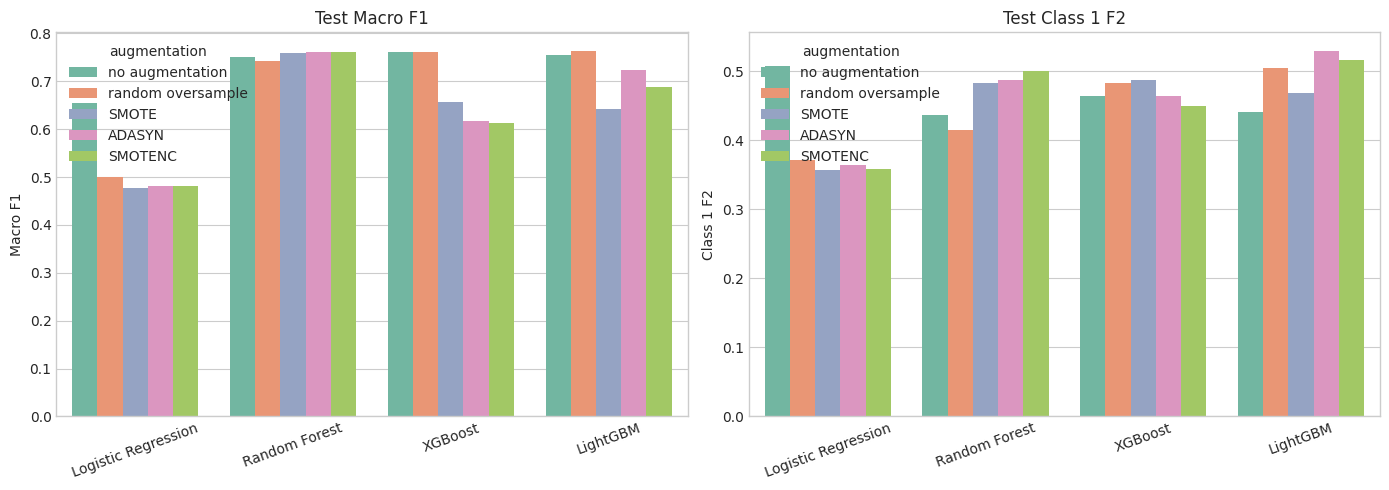

In [18]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=results_df, x='model', y='test_macro_f1', hue='augmentation', ax=axes[0])
axes[0].set_title('Test Macro F1')
axes[0].set_xlabel('')
axes[0].set_ylabel('Macro F1')
axes[0].tick_params(axis='x', rotation=20)

sns.barplot(data=results_df, x='model', y='test_class1_f2', hue='augmentation', ax=axes[1])
axes[1].set_title('Test Class 1 F2')
axes[1].set_xlabel('')
axes[1].set_ylabel('Class 1 F2')
axes[1].tick_params(axis='x', rotation=20)

plt.tight_layout()
plt.show()

Best by test_class1_f2: LightGBM / ADASYN
model                    LightGBM
augmentation               ADASYN
cv_macro_f1              0.766993
cv_class1_f2             0.525669
test_accuracy            0.934625
test_macro_f1            0.724407
test_class1_precision    0.422414
test_class1_recall        0.56582
test_class1_f1           0.483712
test_class1_f2           0.529844


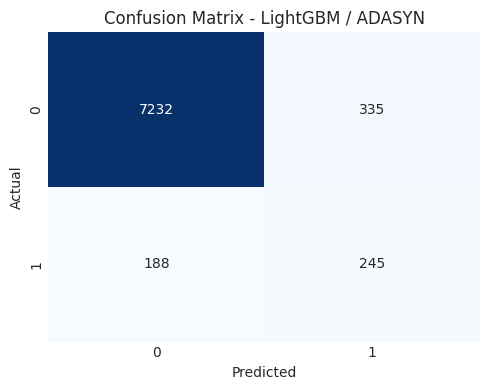

In [19]:
best_row = summary_df.iloc[0]
best_key = (best_row['model'], best_row['augmentation'])
best_pred = predictions[best_key]

print(f"Best by test_class1_f2: {best_key[0]} / {best_key[1]}")
print(best_row.to_string())

cm = confusion_matrix(test_y, best_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Confusion Matrix - {best_key[0]} / {best_key[1]}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.tight_layout()
plt.show()